Mounted at /content/drive


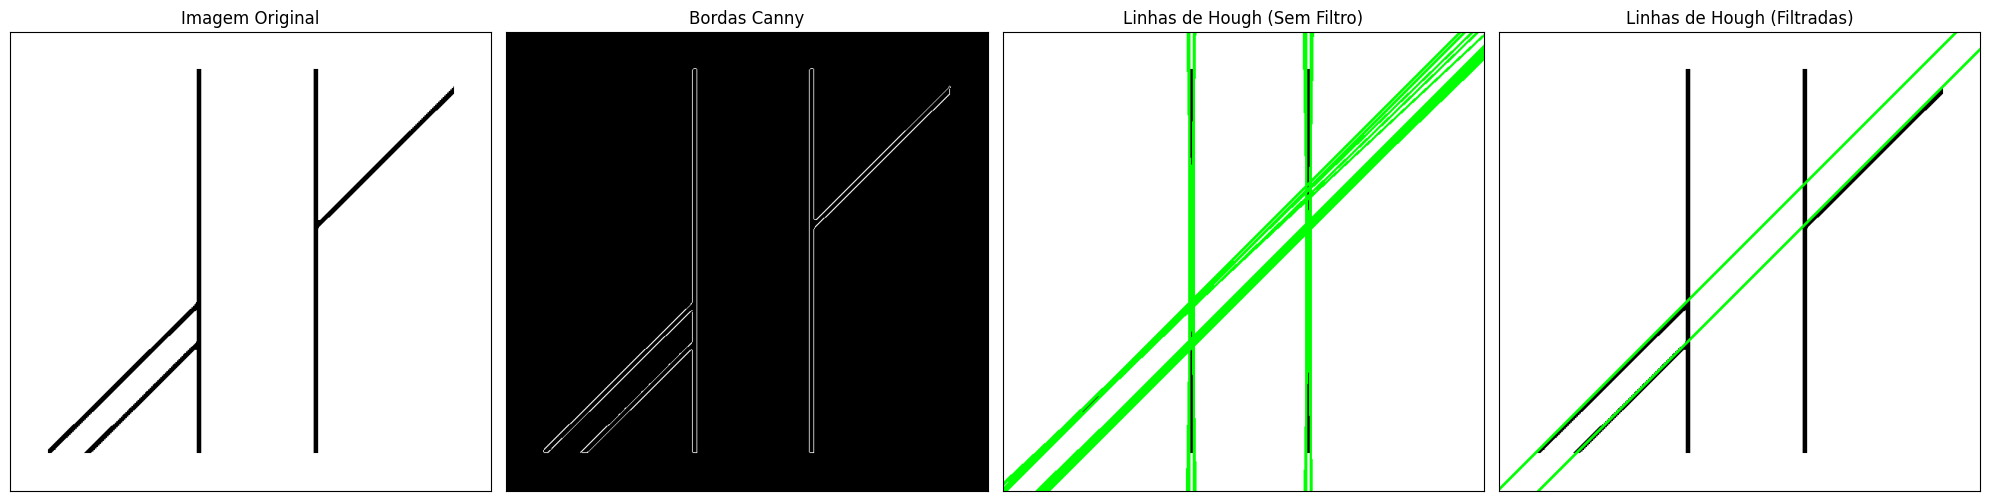

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import cv2
from google.colab.patches import cv2_imshow
import matplotlib.pyplot as plt
import numpy as np

# 1. Carregamento e configuração inicial
# Carrega a imagem do diretório montado no Google Drive
imagem = cv2.imread('/content/drive/MyDrive/Pesquisa/Visão Computacional/imagens/Quest1A/illusion.png')

# Configura a área de plotagem (figura grande para acomodar os subplots)
plt.figure(figsize=(20, 10))

# Plota a imagem original (convertendo de BGR para RGB para o matplotlib exibir as cores corretamente)
plt.subplot(1, 4, 1), plt.imshow(cv2.cvtColor(imagem, cv2.COLOR_BGR2RGB)), plt.title('Imagem Original')
plt.xticks([]), plt.yticks([])

# -------------------------------------------------------------------------
# I) Detecção de Bordas
# -------------------------------------------------------------------------

# 2. Definição de Parâmetros
# Limiares de histerese para o algoritmo de Canny
threshold1 = 50  # Limiar inferior (bordas fracas)
threshold2 = 200 # Limiar superior (bordas fortes)

# 3. Pré-processamento
# Converte a imagem para escala de cinza (obrigatório para Canny e Hough)
gray_img = cv2.cvtColor(imagem, cv2.COLOR_BGR2GRAY)

# 4. Detecção de Bordas
# Aplica o filtro de Canny para gerar um mapa binário de bordas
arestas = cv2.Canny(gray_img, threshold1, threshold2)

# 5. Visualização das Bordas
# Exibe o mapa de bordas resultante
plt.subplot(1, 4, 2), plt.imshow(arestas, cmap='gray'), plt.title('Bordas Canny')
plt.xticks([]), plt.yticks([])


# -------------------------------------------------------------------------
# II) Detecção de Linhas (Transformada de Hough)
# -------------------------------------------------------------------------

# 6. Transformada de Hough (Detecção de Linhas)
# Cria uma cópia da imagem original para desenhar as linhas brutas detectadas
img_resultado = imagem.copy()

# Aplica a Transformada de Hough Padrão
linhas = cv2.HoughLines(
  arestas,             # Imagem de entrada (mapa de bordas)
  rho=1,               # Resolução da distância acumuladora (em pixels)
  theta=np.pi/180,     # Resolução angular acumuladora (em radianos, aqui 1 grau)
  threshold=100        # Mínimo de intersecções (votos) para validar uma linha
)

# 7. Processamento das Linhas Brutas
if linhas is not None:
  for linha in linhas:
    # HoughLines retorna coordenadas polares (rho, theta)
    rho, theta = linha[0]

    # Conversão de coordenadas Polares para Cartesianas para desenho
    a = np.cos(theta)
    b = np.sin(theta)
    x0 = a * rho
    y0 = b * rho

    # Extrapolação dos pontos para desenhar a linha cruzando toda a imagem
    # O fator 1000 garante que a linha seja longa o suficiente
    x1 = int(x0 + 1000 * (-b))
    y1 = int(y0 + 1000 * (a))
    x2 = int(x0 - 1000 * (-b))
    y2 = int(y0 - 1000 * (a))

    # Desenha a linha na imagem cópia (Cor verde, espessura 2)
    cv2.line(img_resultado, (x1, y1), (x2, y2), (0, 255, 0), 2)
else:
    print("Nenhuma linha detectada na etapa inicial.")

# 8. Visualização das Linhas Brutas
plt.subplot(1, 4, 3), plt.imshow(cv2.cvtColor(img_resultado, cv2.COLOR_BGR2RGB)), plt.title('Linhas de Hough (Sem Filtro)')
plt.xticks([]), plt.yticks([])

# -------------------------------------------------------------------------
# III) Filtragem de Linhas Detectadas
# -------------------------------------------------------------------------

lines = linhas
img_filter = imagem.copy()
linhas_aprovadas = []
previews_lines = [] # Lista auxiliar para armazenar linhas já processadas e evitar duplicatas

# 9. Função Auxiliar de Filtragem
# Verifica se a linha atual é muito similar a uma linha já desenhada
def check_previews_close_line(rho, theta, previews_lines, rho_threshold = 10, theta_threshold = 0.1):
    for prev_rho, prev_theta in previews_lines:
        # Se a diferença de distância e ângulo for pequena, considera como duplicata
        if abs(prev_rho - rho) < rho_threshold and abs(prev_theta - theta) < theta_threshold:
            return True
    return False

# Loop de filtragem principal
for linha in lines:
  rho, theta = linha[0]

  # A. Critério de Duplicidade: Verifica se linha similar já existe
  ja_existe = check_previews_close_line(rho, theta, previews_lines)

  # B. Critério de Ângulo: Filtra linhas baseada na inclinação
  # (theta < 0.1 ou theta > 0.8 parece remover linhas verticais/horizontais específicas)
  angulo_ruim = (theta < 0.1 or theta > 0.8)

  # Se a linha é única (não existe) E tem um ângulo válido, é aprovada
  if not ja_existe and not angulo_ruim:
    previews_lines.append((rho, theta)) # Registra para comparação futura
    linhas_aprovadas.append(linha)      # Armazena para desenho final

# 10. Desenho das Linhas Filtradas
img_filtered_draw = imagem.copy() # Nova cópia limpa para o resultado final

if linhas_aprovadas is not None and len(linhas_aprovadas) > 0:
  for filtered_linha in linhas_aprovadas:
    rho, theta = filtered_linha[0]
    # Repete a conversão polar -> cartesiana
    a = np.cos(theta)
    b = np.sin(theta)
    x0 = a * rho
    y0 = b * rho
    x1 = int(x0 + 1000 * (-b))
    y1 = int(y0 + 1000 * (a))
    x2 = int(x0 - 1000 * (-b))
    y2 = int(y0 - 1000 * (a))

    cv2.line(img_filtered_draw, (x1, y1), (x2, y2), (0, 255, 0), 2)
else:
    print("Nenhuma linha restou após a filtragem.")

# 11. Visualização Final Comparativa
plt.subplot(1, 4, 4), plt.imshow(cv2.cvtColor(img_filtered_draw, cv2.COLOR_BGR2RGB)), plt.title('Linhas de Hough (Filtradas)')
plt.xticks([]), plt.yticks([])

# Ajusta o layout para evitar sobreposição e exibe a figura
plt.tight_layout()
plt.show()